##### ARTI 560 - Computer Vision

## Action Recognition - Exercise

### Objective

In this exercise, you will train a deep learning model to recognize three specific human actions using the UCF11 (YouTube Action) dataset and validate the model's real-world performance using external video data.

*[Note: This notebook is based on this GitHub Repository by LearnOpenCV]*

#### Tasks

- Choose three classes from the UCF11 dataset (e.g., Basketball Shooting, Biking, Tennis Swinging, etc.).
- Preprocess the dataset.
- Split the data into training and testing.
- Create and train the model.
- Save the trained model . Important Note: The final trained model must be saved with a filename that includes your name. This is a mandatory step for the submission. 
```
    #Example Code
    student_name = "YourName" # Replace with your actual name
    save_path = f"{student_name}_ucf11_model.h5"
    model.save(save_path)
    print(f"Model saved as {save_path}")
```
= Validate the model on 3 Youtube videos, each clearly showing one of your three chosen action classes.


In [2]:
import os
import random
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


In [ ]:
DATASET_ROOT = Path("lab07-action-recognition/UCF11_updated_mpg")

TARGET_CLASSES = ["diving", "juggle", "swing"]
VIDEO_EXTS = {".avi", ".mp4", ".mpeg", ".mpg", ".mov", ".mkv"}

assert DATASET_ROOT.exists(), f"Dataset folder not found: {DATASET_ROOT.resolve()}"


In [ ]:
def infer_label_from_path(path: Path):

    if len(path.parts) < 3:
        return None

    raw_label = path.parent.parent.name.lower().replace(" ", "_").replace("-", "_")

    label_map = {
        "diving": "diving",
        "soccer_juggling": "juggling",
        "juggling": "juggling",
        "swing": "swinging",
        "swinging": "swinging",
    }

    return label_map.get(raw_label, None)


def collect_videos(root: Path):
    rows = []

    for path in root.rglob("*"):
        if path.is_file() and path.suffix.lower() in VIDEO_EXTS:
            label = infer_label_from_path(path)
            if label is not None:
                rows.append({
                    "video_path": str(path),
                    "label": label,
                    "group": path.parent.name
                })

    df = pd.DataFrame(rows)

    if df.empty:
        raise ValueError(
            "No videos found for diving / juggling / swinging. "
            "Check DATASET_ROOT and folder structure."
        )

    return df.sort_values(["label", "group", "video_path"]).reset_index(drop=True)

df = collect_videos(DATASET_ROOT)

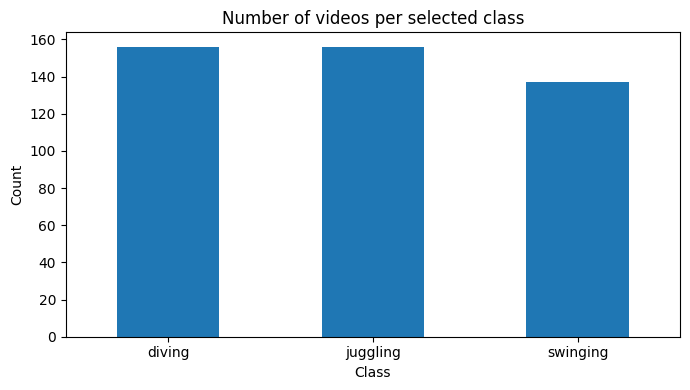

In [7]:
plt.figure(figsize=(7, 4))
df["label"].value_counts().sort_index().plot(kind="bar")
plt.title("Number of videos per selected class")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## train/val/test split


In [8]:
SEED = 17
TEST_SIZE = 0.2
VAL_SIZE_WITHIN_TRAIN = 0.2

train_val_df, test_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=df["label"],
    shuffle=True,
)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=VAL_SIZE_WITHIN_TRAIN,
    random_state=SEED,
    stratify=train_val_df["label"],
    shuffle=True,
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train videos:", len(train_df))
print("Val videos  :", len(val_df))
print("Test videos :", len(test_df))

print("\nTrain class counts:")
print(train_df["label"].value_counts())

print("\nVal class counts:")
print(val_df["label"].value_counts())

print("\nTest class counts:")
print(test_df["label"].value_counts())

Train videos: 287
Val videos  : 72
Test videos : 90

Train class counts:
label
diving      100
juggling    100
swinging     87
Name: count, dtype: int64

Val class counts:
label
diving      25
juggling    25
swinging    22
Name: count, dtype: int64

Test class counts:
label
diving      31
juggling    31
swinging    28
Name: count, dtype: int64


## video frame sampling and preprocessing

Each video is converted into a fixed-length sequence of frames.


In [9]:
IMG_SIZE = 160
NUM_FRAMES = 20
BATCH_SIZE = 8
AUTOTUNE = tf.data.AUTOTUNE


In [10]:
def load_video_frames(video_path, num_frames=NUM_FRAMES, img_size=IMG_SIZE):
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total <= 0:
        frames = []
        while True:
            ok, frame = cap.read()
            if not ok:
                break
            frames.append(frame)
        total = len(frames)
        if total == 0:
            cap.release()
            return np.zeros((num_frames, img_size, img_size, 3), dtype=np.float32)
        indices = np.linspace(0, total - 1, num_frames).astype(int)
        sampled = [frames[i] for i in indices]
    else:
        indices = np.linspace(0, max(total - 1, 0), num_frames).astype(int)
        sampled = []
        for idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
            ok, frame = cap.read()
            if not ok or frame is None:
                if sampled:
                    frame = sampled[-1]
                else:
                    frame = np.zeros((img_size, img_size, 3), dtype=np.uint8)
            sampled.append(frame)

    cap.release()

    processed = []
    for frame in sampled:
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = cv2.resize(frame, (img_size, img_size))
        frame = frame.astype(np.float32) / 255.0
        processed.append(frame)

    return np.array(processed, dtype=np.float32)


Sample video
Label: diving
Frame tensor shape: (20, 160, 160, 3)


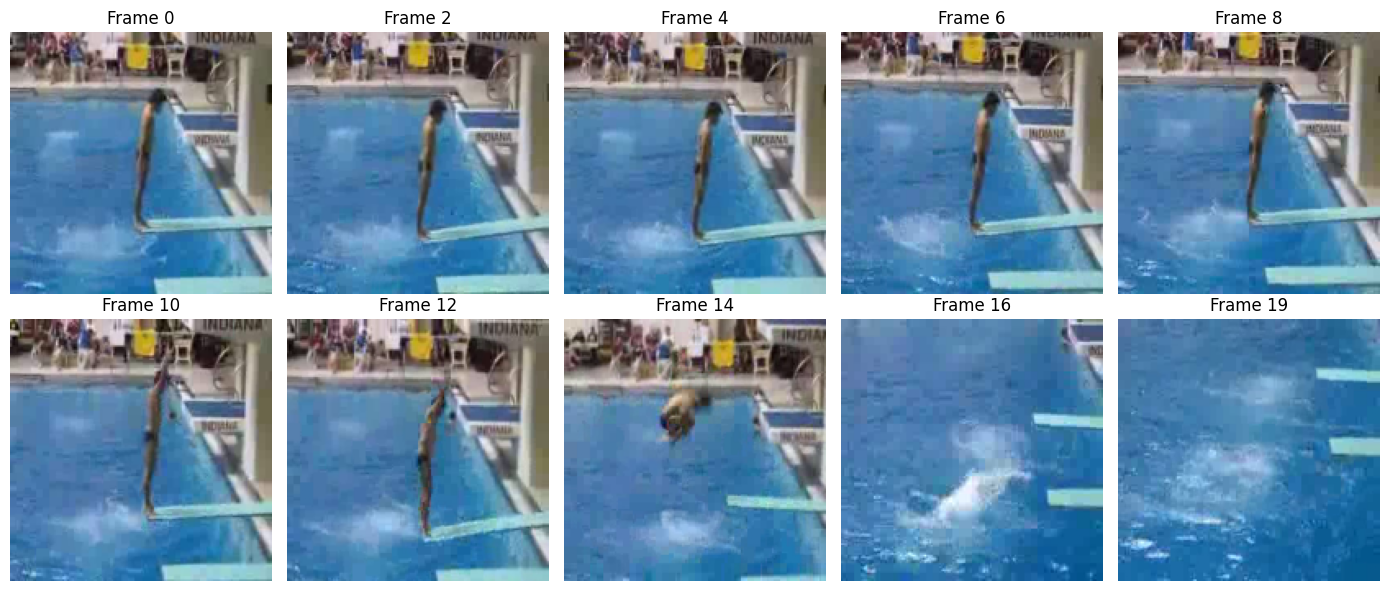

In [19]:
sample_path = df.iloc[0]["video_path"]
sample_label = df.iloc[0]["label"]
sample_frames = load_video_frames(sample_path)

print("Sample video")
print("Label:", sample_label)
print("Frame tensor shape:", sample_frames.shape)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for ax, idx in zip(axes.flat, np.linspace(0, NUM_FRAMES - 1, 10).astype(int)):
    ax.imshow(sample_frames[idx])
    ax.set_title(f"Frame {idx}")
    ax.axis("off")
plt.tight_layout()
plt.show()


## input pipeline

In [15]:
CLASS_NAMES = ["diving", "juggling", "swinging"]
CLASS_TO_IDX = {name: i for i, name in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {i: name for name, i in CLASS_TO_IDX.items()}

print(CLASS_TO_IDX)

{'diving': 0, 'juggling': 1, 'swinging': 2}


In [17]:
def make_numpy_dataset(split_df):
    X = np.stack(
        [load_video_frames(p) for p in tqdm(split_df["video_path"], desc="Loading videos")]
    )
    y = split_df["label"].map(CLASS_TO_IDX).to_numpy(dtype=np.int32)
    return X, y

In [ ]:
X_train, y_train = make_numpy_dataset(train_df)
X_val, y_val = make_numpy_dataset(val_df)
X_test, y_test = make_numpy_dataset(test_df)

In [ ]:
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(len(X_train)).batch(BATCH_SIZE).prefetch(AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE).prefetch(AUTOTUNE)
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH_SIZE).prefetch(AUTOTUNE)

## build video classification model

I use a TimeDistributed(MobileNetV2) for per-frame spatial features and a GRU for temporal modeling across frames


In [21]:
def build_model(num_frames=NUM_FRAMES, img_size=IMG_SIZE, num_classes=len(TARGET_CLASSES)):
    frame_inputs = keras.Input(shape=(num_frames, img_size, img_size, 3), name="video")

    base_cnn = keras.applications.MobileNetV2(
        include_top=False,
        weights="imagenet",
        input_shape=(img_size, img_size, 3),
        pooling="avg"
    )
    base_cnn.trainable = False

    x = layers.TimeDistributed(base_cnn)(frame_inputs)
    x = layers.GRU(128, dropout=0.3, recurrent_dropout=0.0)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(frame_inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

model = build_model()
model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ video (InputLayer)              │ (None, 20, 160, 160,   │             0 │
│                                 │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 20, 1280)       │     2,257,984 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 128)            │       541,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,816,323 (10.74 MB)

 Trainable params: 558,339 (2.13 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

## train the model

In [22]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 98s 755ms/step - accuracy: 0.7805 - loss: 0.5649 - val_accuracy: 0.9306 - val_loss: 0.2386 - learning_rate: 0.0010
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 110ms/step - accuracy: 0.9756 - loss: 0.1015 - val_accuracy: 0.9444 - val_loss: 0.1666 - learning_rate: 0.0010
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 112ms/step - accuracy: 0.9756 - loss: 0.0664 - val_accuracy: 0.9583 - val_loss: 0.1539 - learning_rate: 0.0010
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 110ms/step - accuracy: 0.9965 - loss: 0.0284 - val_accuracy: 0.9306 - val_loss: 0.1892 - learning_rate: 0.0010
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 1.0000 - loss: 0.0080
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 111ms/step - accuracy: 1.0000 - loss: 0.0080 - val_accuracy: 0.9722 - val_loss: 0.1907 - learning_rate: 0.0010
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 111ms/step - accuracy: 1.0000 - loss: 0.0047 - v

,accuracy,loss,val_accuracy,val_loss,learning_rate
5,1.0,0.004686,0.958333,0.169952,0.000500
6,1.0,0.002535,0.958333,0.165808,0.000500
7,1.0,0.002187,0.958333,0.170615,0.000250
8,1.0,0.002596,0.958333,0.169694,0.000250
9,1.0,0.003887,0.958333,0.171076,0.000125


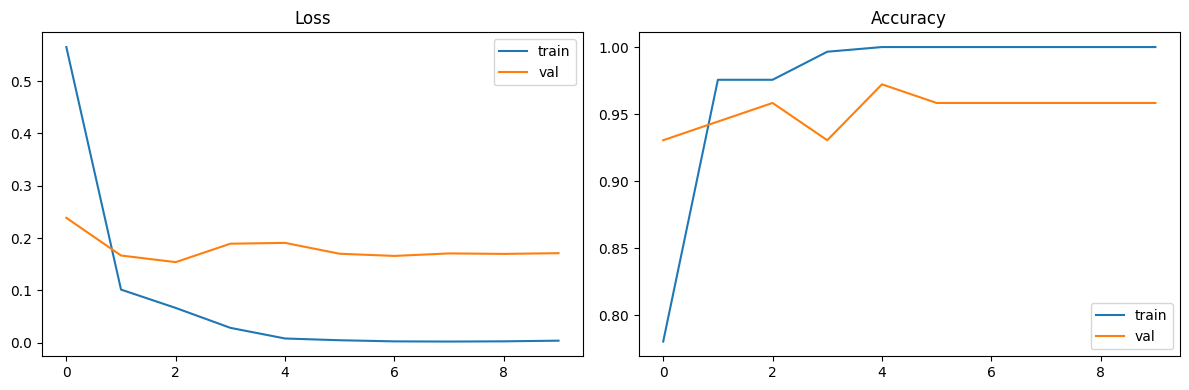

In [23]:
history_df = pd.DataFrame(history.history)
display(history_df.tail())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="train")
axes[1].plot(history.history["val_accuracy"], label="val")
axes[1].set_title("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()


## evaluate on the test set

In [ ]:
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=1)
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=1)

In [ ]:
y_prob = model.predict(X_test, verbose=1)
y_pred = np.argmax(y_prob, axis=1)

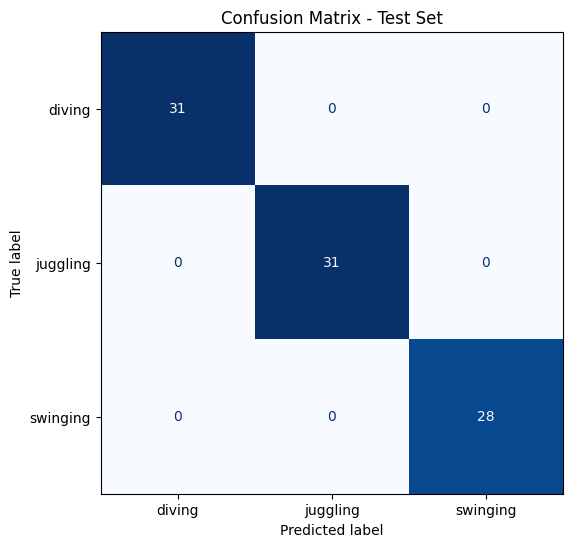

In [27]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix - Test Set")
plt.show()

## save the trained model


In [ ]:
model_path = "farah_ucf11_model.h5"
model.save(model_path)

## Predict on an external youtube videos
I used the following videos for out of distribution prediction:
1. https://www.youtube.com/shorts/Mdwoaw5xRME for diving
2. https://www.youtube.com/shorts/idKn1-8Kqa8 for swinging
3. https://www.youtube.com/shorts/FGUbaSQ50CI from soccer juggling


Testing: diving_test.mp4


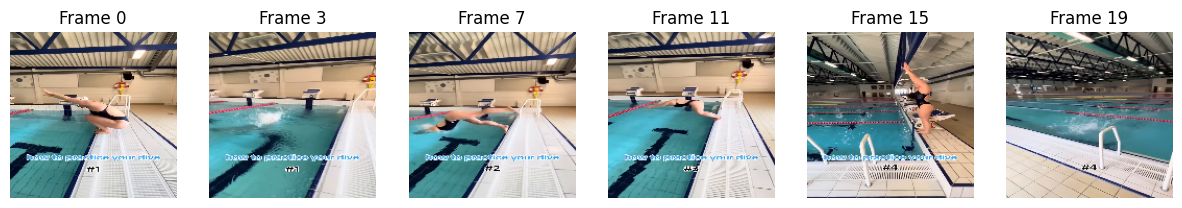

Prediction: diving (0.9980)
Class probabilities:
   diving: 0.9980
   juggling: 0.0017
   swinging: 0.0002
--------------------------------------------------

Testing: juggling_test.mp4


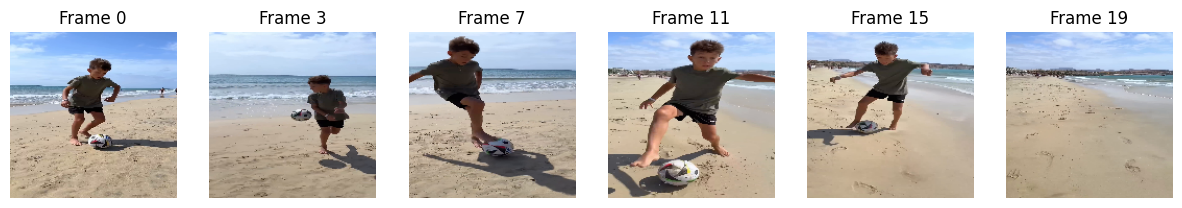

Prediction: juggling (0.9983)
Class probabilities:
   diving: 0.0010
   juggling: 0.9983
   swinging: 0.0007
--------------------------------------------------

Testing: swinging_test.mp4


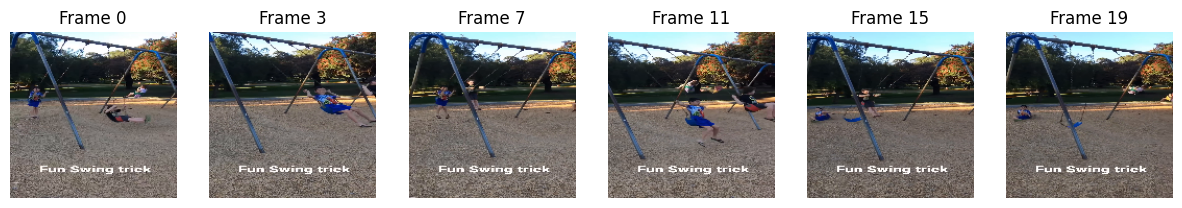

Prediction: swinging (0.9992)
Class probabilities:
   diving: 0.0001
   juggling: 0.0007
   swinging: 0.9992
--------------------------------------------------


In [ ]:
TEST_DIR = Path("/lab07-action-recognition")

TEST_VIDEOS = [
    "diving_test.mp4",
    "juggling_test.mp4",
    "swinging_test.mp4",
]

def show_frames(video_array, num_frames=6):
    idxs = np.linspace(0, len(video_array) - 1, num_frames).astype(int)

    plt.figure(figsize=(15, 3))
    for i, idx in enumerate(idxs):
        plt.subplot(1, num_frames, i + 1)
        plt.imshow(video_array[idx])
        plt.title(f"Frame {idx}")
        plt.axis("off")
    plt.show()


for video_name in TEST_VIDEOS:
    video_path = TEST_DIR / video_name

    if not video_path.exists():
        print(f"Missing: {video_path}")
        continue

    print(f"\nTesting: {video_name}")

    video_array = load_video_frames(str(video_path))
    show_frames(video_array)

    x_infer = np.expand_dims(video_array, axis=0)
    probs = model.predict(x_infer, verbose=0)[0]
    pred_idx = int(np.argmax(probs))
    pred_label = IDX_TO_CLASS[pred_idx]
    confidence = float(np.max(probs))

    print(f"Prediction: {pred_label} ({confidence:.4f})")
    print("Class probabilities:")
    for i, p in enumerate(probs):
        print(f"   {IDX_TO_CLASS[i]}: {p:.4f}")

    print("-" * 50)